In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df_ventas = pd.read_csv('../dataset/procesado/ventas_limpio.csv')

df_ventas.head()

,ordenID,productoID,UnitPrice,Quantity,NombreProducto,categoriaID,clienteID,fecha,NombreCategoria,TotalVenta,Mes,CategoriaVentas
0,10248,11,14.0,12,Queso Cabrales,4,VINET,1996-07-04,Dairy Products,168.0,1996-07,Media
1,10248,42,9.8,10,Singaporean Hokkien Fried Mee,5,VINET,1996-07-04,Grains/Cereals,98.0,1996-07,Baja
2,10248,72,34.8,5,Mozzarella di Giovanni,4,VINET,1996-07-04,Dairy Products,174.0,1996-07,Media
3,10249,14,18.6,9,Tofu,7,TOMSP,1996-07-05,Produce,167.4,1996-07,Media
4,10249,51,42.4,40,Manjimup Dried Apples,7,TOMSP,1996-07-05,Produce,1696.0,1996-07,Alta


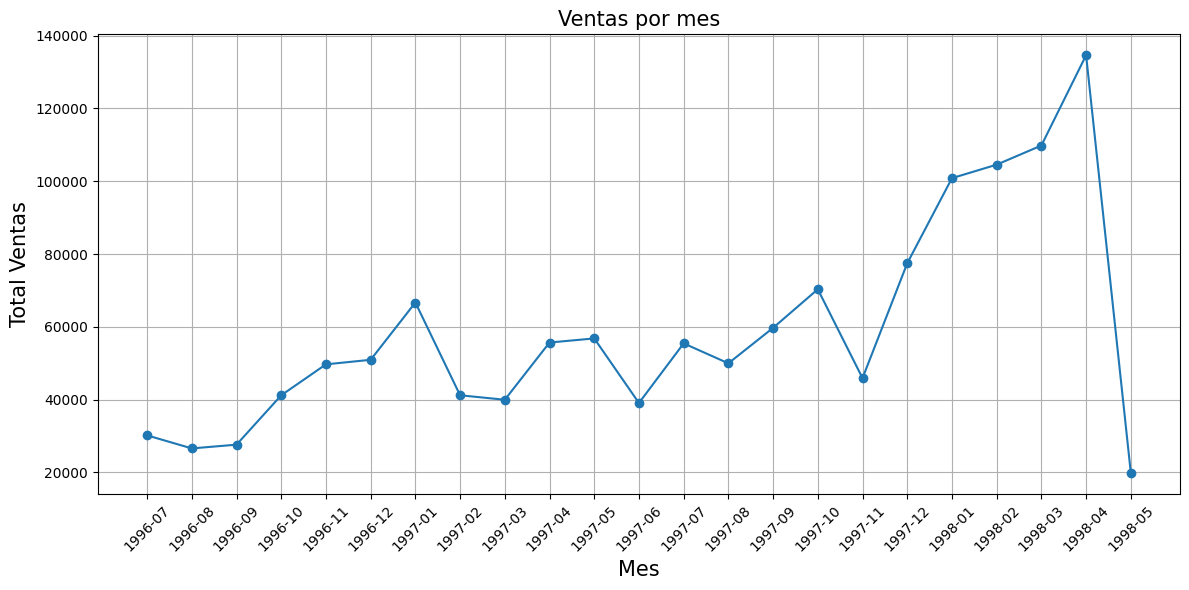

In [162]:
# Ventas por mes
ventas_mes = df_ventas.groupby('Mes', as_index = False).agg(
    TotalVenta = ('TotalVenta', 'sum')).sort_values('Mes')

plt.figure(figsize = (12, 6))
plt.plot(
    ventas_mes['Mes'], ventas_mes['TotalVenta'], marker = 'o'
)
plt.xticks(rotation = 45)
plt.title('Ventas por mes', fontsize = 15)
plt.xlabel('Mes', fontsize = 15)
plt.ylabel('Total Ventas', fontsize = 15)
plt.grid()
plt.tight_layout()
plt.show()


## Insight – Ventas por mes
```
Analizando las ventas por mes, se observa una tendencia general de crecimiento a lo largo del periodo, 
lo que indica una evolución positiva del negocio, durante 1997 se mantuvieron en un rango variable sin dirección clara,
es a partir de enero de 1998 donde se produce un salto significativo, con ventas que superan los $100k
representando más del doble del promedio de 1997.

El mes con mayor volumen de ventas es abril de 1998, lo que representa el punto máximo de desempeño, 
sin embargo, en mayo de 1998 se evidencia una caída bastante fuerte en comparación con los meses anteriores, 
esto podría estar relacionado con datos incompletos que afecta el comportamiento normal de la evolución positiva.

En conclusión, el análisis muestra una tendencia alcista con picos y caidas mensuales, 
lo que sugiere validar datos de mayo de 1998 y continuar el seguimiento para confirmar si el crecimiento del negocio se sostiene.


```

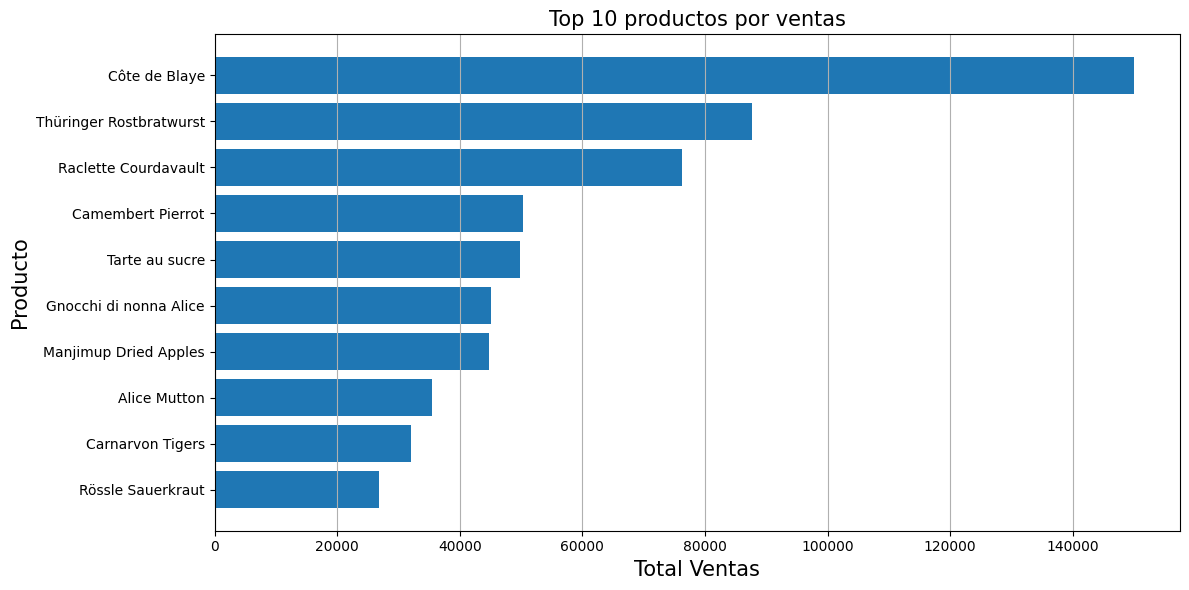

In [6]:
# Top 10 productos más vendidos
top_productos = df_ventas.groupby('NombreProducto', as_index = False).agg(
    TotalVenta = ('TotalVenta', 'sum')).sort_values('TotalVenta', ascending = False).head(10)

plt.figure(figsize = (12, 6))
plt.barh(
    top_productos['NombreProducto'], top_productos['TotalVenta']
)
plt.gca().invert_yaxis()
plt.title('Top 10 productos por ventas', fontsize = 15)
plt.xlabel('Total Ventas', fontsize = 15)
plt.ylabel('Producto', fontsize = 15)
plt.grid(axis = 'x')
plt.tight_layout()  
plt.show()


## Insight – Top 10 Productos por Ventas
```
El producto *Côte de Blaye* lidera ampliamente las ventas, superando por una diferencia significativa al resto de productos del top 10, se oberva que existe una concentración importante de ingresos en pocos productos, eso indica que el negocio depende en gran medida de su rendimiento.

Se recomienda evaluar estrategias para potenciar los productos de mayor demanda y analizar oportunidades de crecimiento o diversificación en el catálogo de productos.


```

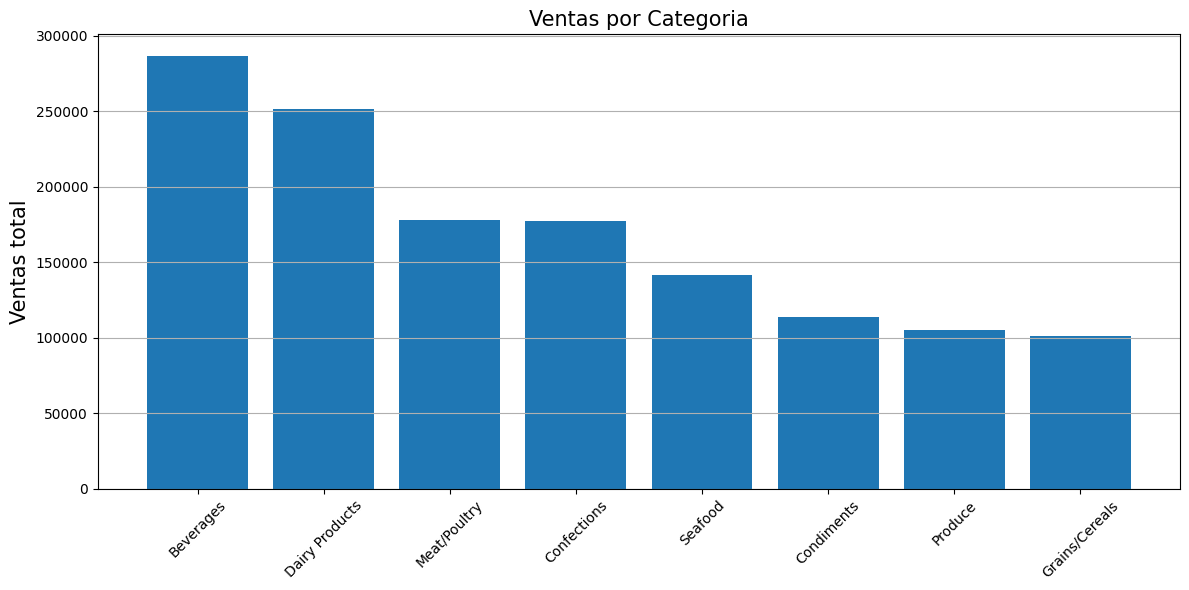

In [10]:
# Ventas por categoria
ventas_categoria = df_ventas.groupby('NombreCategoria', as_index = False).agg(
    TotalVenta = ('TotalVenta', 'sum')).sort_values('TotalVenta', ascending = False)

plt.figure(figsize = (12, 6))
plt.bar(
    ventas_categoria['NombreCategoria'], ventas_categoria['TotalVenta']
)
plt.xticks(rotation = 45)
plt.title('Ventas por Categoria', fontsize = 15)
plt.ylabel('Ventas total', fontsize = 15)
plt.grid(axis = 'y')
plt.tight_layout()
plt.show()


## Insight – Ventas por categoria
```
El análisis muestra que la categoria *Berevages* lidera ventas totales, seguida de *Dairy Products*, ambas superando los $250k en ingresos.
Se observa también la distribución relativamente equilibrada entre varias categorías, lo que indica que el negocio no depende exlusivamente de una sola fuente de ingreso

En este cnotexto, se recomienda reforzar las categorias con mayor rendimiento y evaluar oportunidades de crecimiento.
```

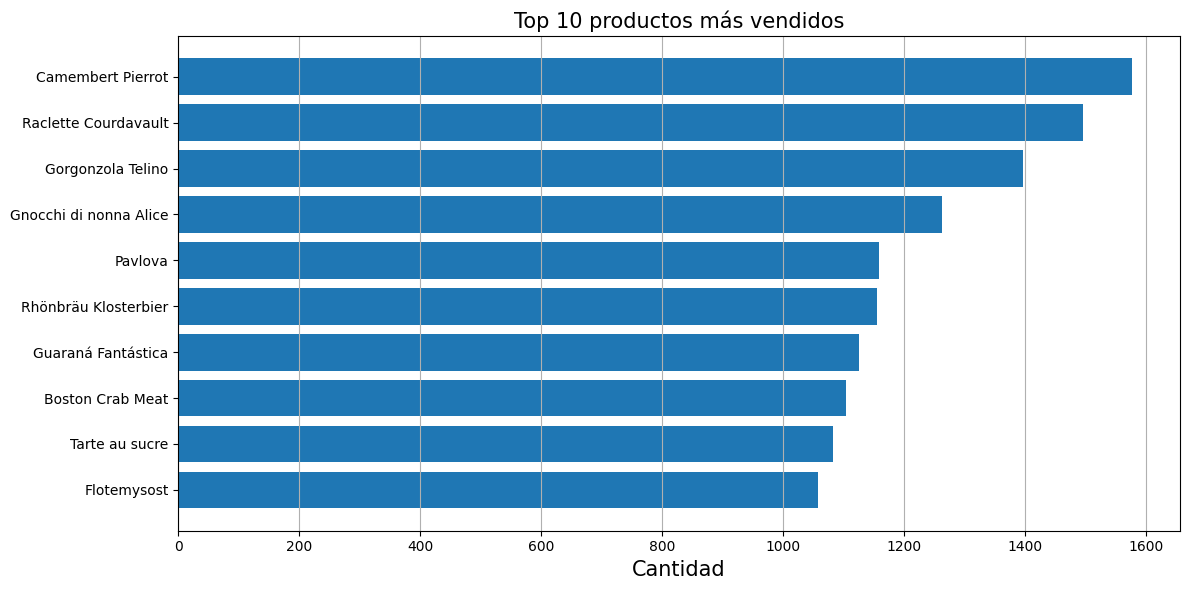

In [6]:
# Top 10 cantidad de productos vendidos
productos_cantidad_ventas = df_ventas.groupby('NombreProducto', as_index = False).agg(
    TotalCantidad = ('Quantity', 'sum')).sort_values('TotalCantidad', ascending = False).head(10)

plt.figure(figsize = (12, 6))
plt.barh(
    productos_cantidad_ventas['NombreProducto'], productos_cantidad_ventas['TotalCantidad']
)
plt.title('Top 10 productos más vendidos', fontsize = 15)
plt.gca().invert_yaxis()
plt.xlabel('Cantidad', fontsize = 15)
plt.grid(axis = 'x')
plt.tight_layout()
plt.show()


## Insight – Productos más vendidos
```
Los datos muestran que productos como *Camembert Pierrot*, *Raclette Courdavault* y *Gorgonzola Telino* lideran en volumen de ventas, se observa que los productos más vendidos en cantidad no necesariamente coinciden con los de mayor ingreso (como se vio en el análisis del primer gráfico), lo que sugiere diferencias en precios o posicionamiento dentro del catálogo de productos.

Se recomienda asegurar la disponibilidad y stock de los productos con mayor volumen en ventas, ya que representa una alta rotación y son clave para la continuidad del negocio
```

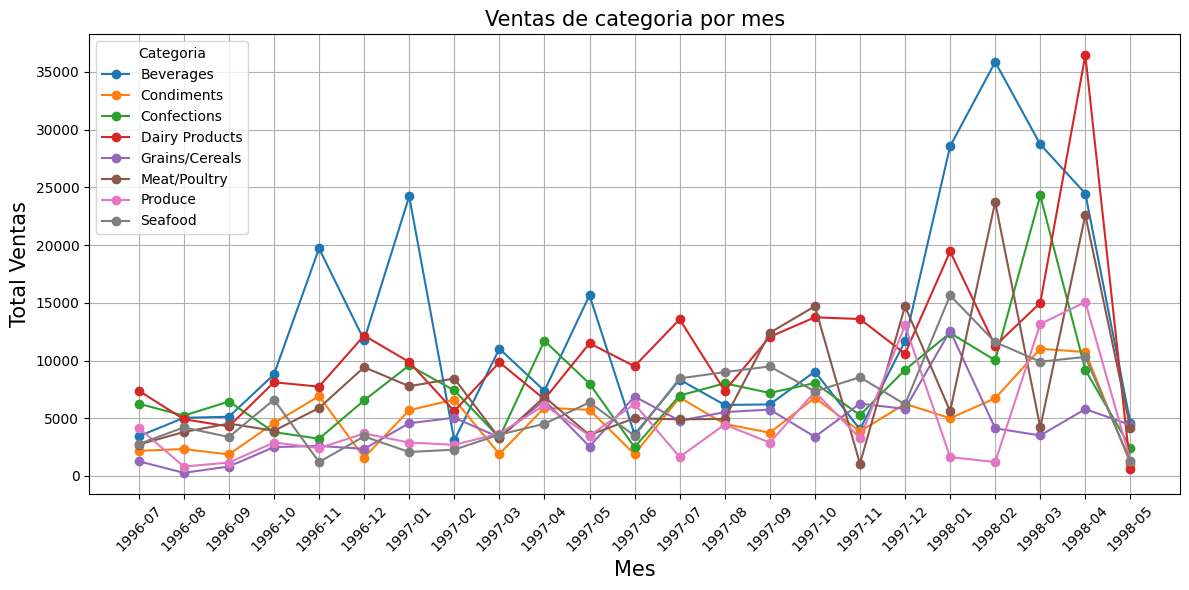

In [7]:
# Ventas de categoria por mes
ventas_categorias_mensual = df_ventas.groupby(['Mes', 'NombreCategoria'], as_index = False).agg(
    TotalVenta = ('TotalVenta', 'sum')
)
plt.figure(figsize = (12, 6))
for categoria in ventas_categorias_mensual['NombreCategoria'].unique():
    filtro_categorias = ventas_categorias_mensual[ventas_categorias_mensual['NombreCategoria'] == categoria]
    plt.plot(
        filtro_categorias['Mes'], 
        filtro_categorias['TotalVenta'], 
        marker = 'o', label = categoria
    )
plt.title('Ventas de categoria por mes', fontsize = 15)
plt.xlabel('Mes', fontsize = 15)
plt.ylabel('Total Ventas', fontsize = 15)
plt.legend(title = 'Categoria')
plt.xticks(rotation = 45)
plt.grid()
plt.tight_layout()
plt.show()

## Insight – Ventas de categoria por mes
```
El análisis muestra que las ventas por categoria se mantiene relativamente estables a lo largo del tiempo, con variaciones mensuales en cada una de ellas, Se observan picos importantes en 1998, principalmente en las categorias *Beverages* y *Dairy Products*, superando los $35k, eso indica un incremento significativo en las demandas de ese periodo, otras categorias también tienen aumentos en ese mismo año, aunque con menor magnitud.

Se recomienda analizar las categorias con mayor crecimiento en 1998, como *Beverages* y *Dairy Products*, para identificar los factores que impulsaron su incremento y replicar esas estrategias en otras categorias. Asimismo validar la información de mayo de 1988, la caída significativa podría afectar la interpretación de la tendencia
```

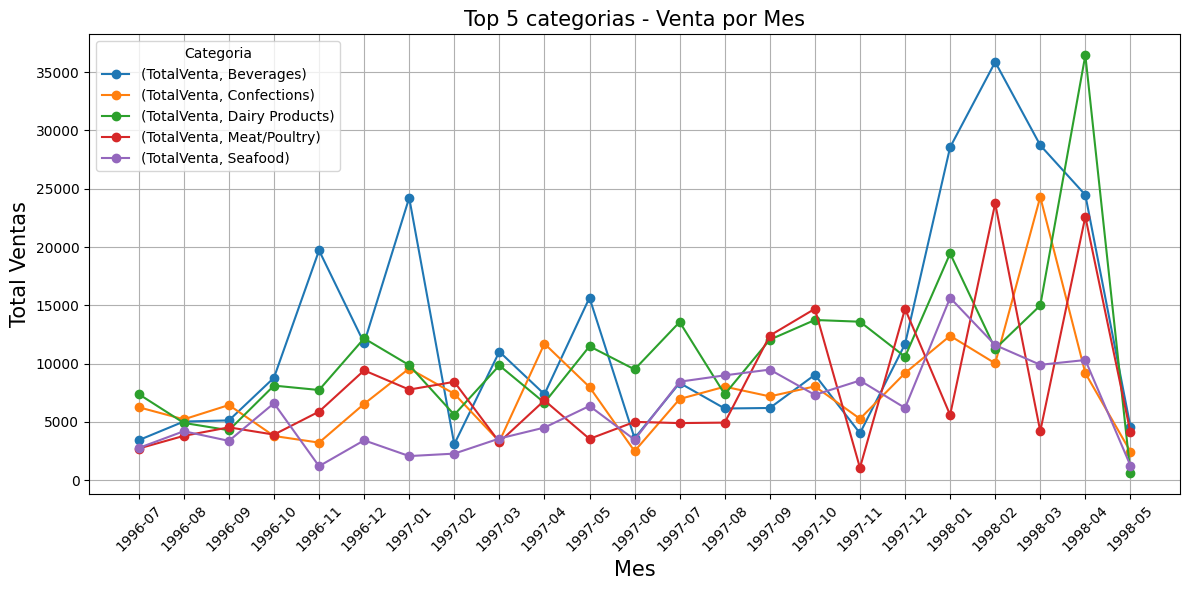

In [118]:
# Top 5 categorias en el tiempo
top_categorias = df_ventas.groupby('NombreCategoria').agg(
    TotalVenta = ('TotalVenta', 'sum')).nlargest(5, 'TotalVenta').index

df_top = df_ventas[df_ventas['NombreCategoria'].isin(top_categorias)]

ventas = df_top.groupby(['Mes', 'NombreCategoria']).agg(
    TotalVenta = ('TotalVenta', 'sum')).unstack()

ventas.plot(figsize = (12, 6), marker = 'o')

plt.title('Top 5 categorias - Venta por Mes', fontsize = 15)
plt.xlabel('Mes', fontsize = 15)
plt.ylabel('Total Ventas', fontsize = 15)
plt.legend(title = 'Categoria')
plt.xticks(rotation=45, ticks=range(len(ventas.index)), labels=ventas.index)
plt.tight_layout()
plt.grid()
plt.show()


## Insight – Top 5 categorías con mayor venta en el tiempo
```
Al enfocarse en las 5 categorias con mayores ventas, se puede observar con mayor claridad su comportamiento a lo largo del tiempo, Las categorias *Beverages* y *Dairy Products* destacan con los picos más altos, especialmente en 1998, otras categorias  como *confections* y *Meat/Poultry* muestran un comportamiento variable, con incrementos en ciertos meses.

Se recomienda analizar las fluctuaciones en las categorias *Confections* y *Meat/Poultry* para identificar que afectan su variabilidad, Asimismo se podrían replicar estrategias aplicadas en las categorias lideres como *Beverages* y *Dairy Products* con el objetivo de impulsar un crecimiento más estable y sostenido
```

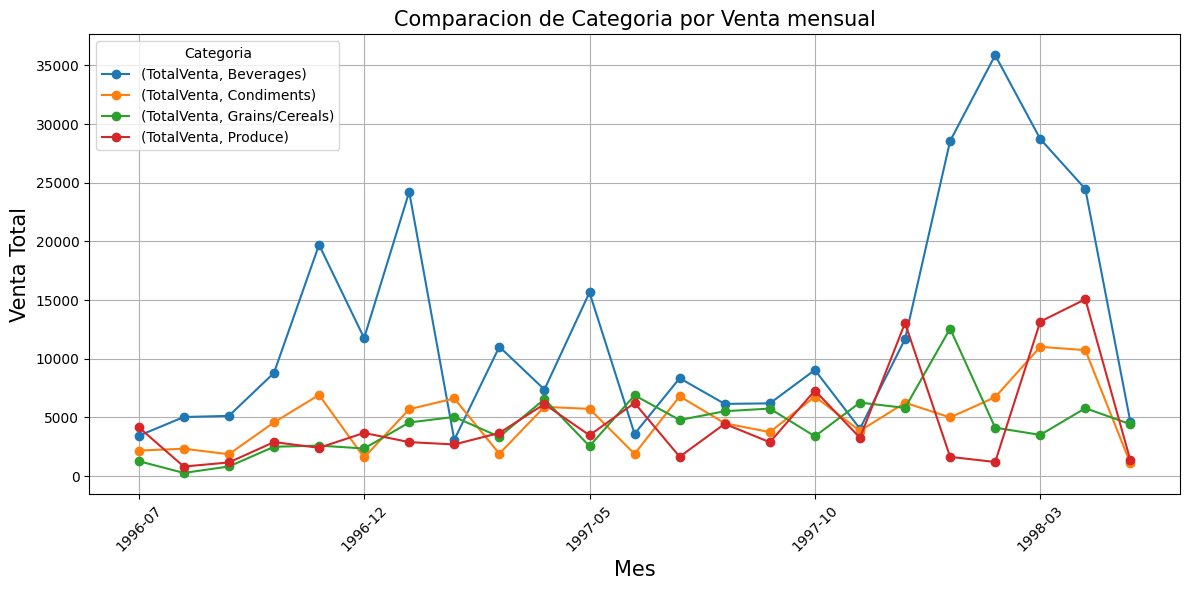

In [9]:
# Comparación de Ventas de Categorias
categorias_comparacion = ['Grains/Cereals', 'Condiments', 'Produce', 'Beverages']

df_filtro = df_ventas[df_ventas['NombreCategoria'].isin(categorias_comparacion)]

ventas_categorias_comparadas = df_filtro.groupby(['Mes', 'NombreCategoria']).agg(
    TotalVenta = ('TotalVenta', 'sum')).unstack()

ventas_categorias_comparadas.plot(figsize = (12, 6), marker = 'o')
plt.title('Comparacion de Categoria por Venta mensual', fontsize = 15)
plt.xlabel('Mes', fontsize = 15)
plt.ylabel('Venta Total', fontsize = 15)
plt.xticks(rotation=45)
plt.legend(title = 'Categoria')
plt.grid()
plt.tight_layout()
plt.show()


## Insight – Comparación de categorías
``` 
Al comparar la categoria lider en ventas *Beverages* con categorias de menor volumen como *Condiments*, *Grains/Cereals* y *Produce*, se observa quna diferencia significativa en el nivel de ventas a lo largo del tiempo,
lo que indica una menor contribución al incremento general de ingresos.

En este contexto, se sugiere analizar el comportamiento de estas categorias para identificar oportunidades de crecimiento y reducir la dependencia de las categorias lideres.

```

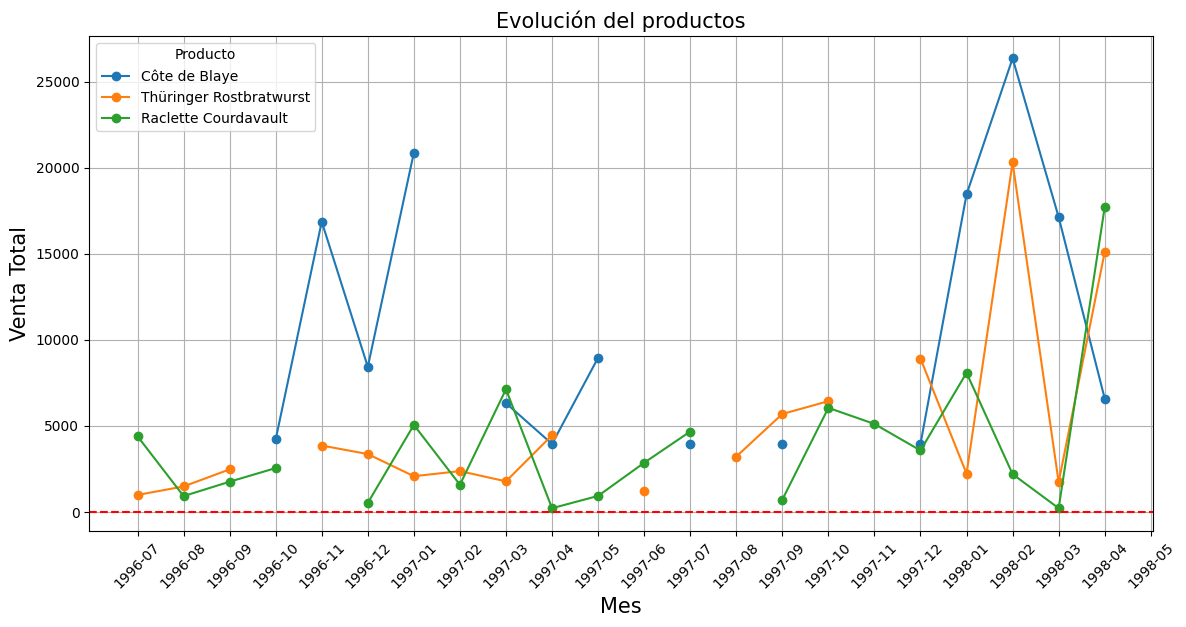

In [13]:
# Evolución de Productos top 3 con más venta
top_productos = df_ventas.groupby('NombreProducto').agg(
    TotalVenta = ('TotalVenta', 'sum')).nlargest(3, 'TotalVenta').index

meses_ordenados = sorted(df_ventas['Mes'].unique())

plt.figure(figsize = (12, 6))

# lo haremos con loop para multiples productos
for producto in top_productos:
    df_producto_ventas = df_ventas[df_ventas['NombreProducto'] == producto]
    ventas_mensuales = df_producto_ventas.groupby('Mes').agg(
        TotalVenta = ('TotalVenta', 'sum')
    )
    ventas_mensuales = ventas_mensuales.reindex(meses_ordenados)
    plt.plot(ventas_mensuales.index, ventas_mensuales.values,
            marker = 'o', label = producto)
plt.grid()
plt.legend(title = 'Producto')
plt.title('Evolución del productos', fontsize = 15)
plt.xlabel('Mes', fontsize = 15)
plt.ylabel('Venta Total', fontsize = 15)
plt.axhline(0, color = 'red', linestyle = '--')
plt.tight_layout()
plt.xticks(rotation = 45)
plt.show()

## Insight – Evolución de productos más vendidos a lo largo del tiempo
```
El análisis muestra que los productos líderes presentan un comportamiento altamente variable a lo largo del  
tiempo, con picos de ventas en meeses específicos, especialmente en 1998, *Côte de Blaye* descata con los 
valores más altos, aunque sin una tendencia de crecimiento sostenido, las ventas de estos productos dependen de 
picos de demanda más que de un crecimiento estable en el tiempo.

Se recomienda analizar los factores que generan los picos de ventas en estos productos para replicarlos de 
manera más consistente y lograr un comportamiento de ventas más estable.

```


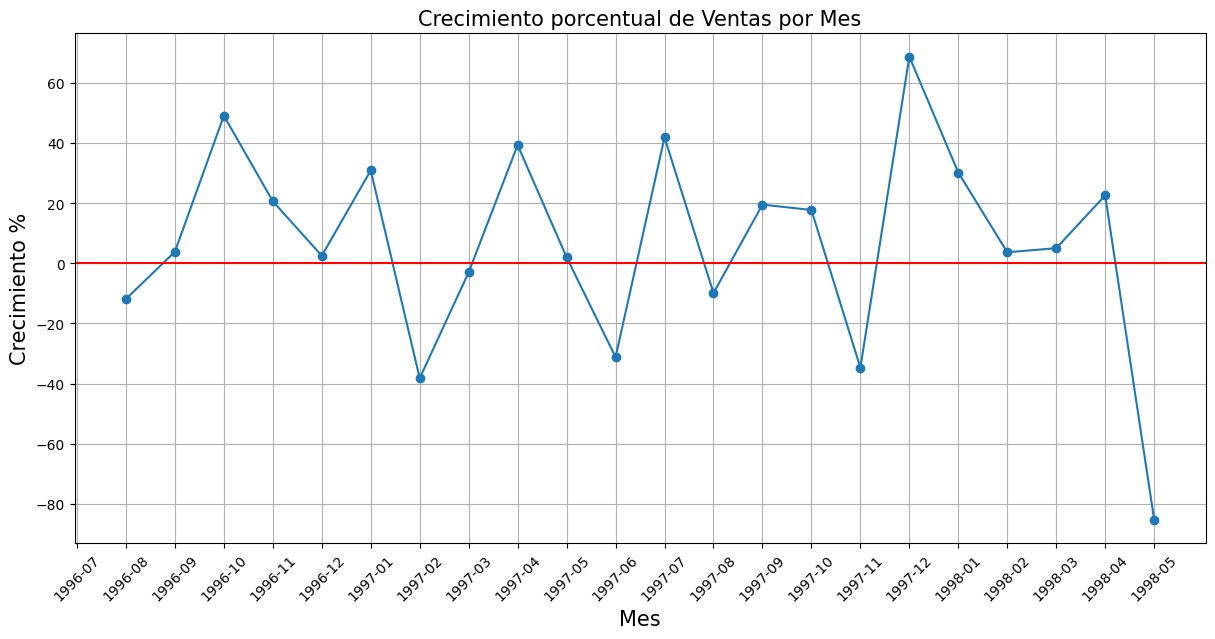

,Mes,TotalVenta,Crecimiento
0,1996-07,30192.10,NaN
1,1996-08,26609.40,-11.87
2,1996-09,27636.00,3.86
3,1996-10,41203.60,49.09
4,1996-11,49704.00,20.63
5,1996-12,50953.40,2.51
6,1997-01,66692.80,30.89
7,1997-02,41207.20,-38.21
8,1997-03,39979.90,-2.98
9,1997-04,55699.39,39.32


In [134]:
# Crecimiento porcentual - comparar cada mes con el anterior en %
df_ventas_mensual = df_ventas.groupby('Mes', as_index = False).agg(
    TotalVenta = ('TotalVenta', 'sum')).sort_values('Mes')

df_ventas_mensual['Crecimiento'] = df_ventas_mensual['TotalVenta'].pct_change() * 100

plt.figure(figsize = (12, 6))
plt.plot(
    df_ventas_mensual['Mes'], df_ventas_mensual['Crecimiento'], marker = 'o'
)
plt.xticks(rotation = 45)
plt.axhline(0, color = 'red', linestyle = '-')
plt.tight_layout()
plt.title('Crecimiento porcentual de Ventas por Mes', fontsize = 15)
plt.xlabel('Mes', fontsize = 15)
plt.ylabel('Crecimiento %', fontsize = 15)
plt.grid()
plt.show()
df_ventas_mensual.round(2)